# EYE FOR BLIND
This notebook will be used to prepare the capstone project 'Eye for Blind'

In [91]:
# -------------------------------------------------------------------------
# Import all the required libraries
# -------------------------------------------------------------------------
import glob
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from collections import Counter
import os
import cv2
from tqdm import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import sentence_bleu

import tensorflow as tf
from tensorflow import keras
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.applications import InceptionV3
from keras.models import Model
from keras.layers import Dense, Embedding, GRU, LSTMCell

In [5]:
# -------------------------------------------------------------------------
# Define origianl data path
# -------------------------------------------------------------------------
image_dir = 'data/Flickr_8k/Images'
caption_path = 'data/Flickr_8k/captions.txt'

# -------------------------------------------------------------------------
# Define a directory to save the features
# -------------------------------------------------------------------------
features_dir = 'data/image_features'

if not os.path.exists(features_dir):
    os.makedirs(features_dir)

# -------------------------------------------------------------------------
# Define the batch size
# -------------------------------------------------------------------------
batch_size = 32

## I. Data understanding
1.Import the dataset and read image & captions into two seperate variables

2.Visualise both the images & text present in the dataset

3.Create a dataframe which summarizes the image, path & captions as a dataframe

4.Create a list which contains all the captions & path

5.Visualise the top 30 occuring words in the captions



### 1. Import the dataset and read image & captions into two seperate variables

In [6]:
# -------------------------------------------------------------------------
# Import the dataset and read the image into a seperate variable
# -------------------------------------------------------------------------
img_path_lst = glob.glob(os.path.join(image_dir, "*.jpg"),recursive=True)
print("The total images present in the dataset: {}".format(len(img_path_lst)))

The total images present in the dataset: 8091


In [7]:
# -------------------------------------------------------------------------
# Import the dataset and read the text file into a seperate variable
# Load the captions
# -------------------------------------------------------------------------
def load_doc(filename):
    with open(filename, 'r') as file:
        text = file.read()
    return text

doc = load_doc(caption_path)
print(doc[:300])

image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .
1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg,A little girl climbing


### 2. Visualise images and texts

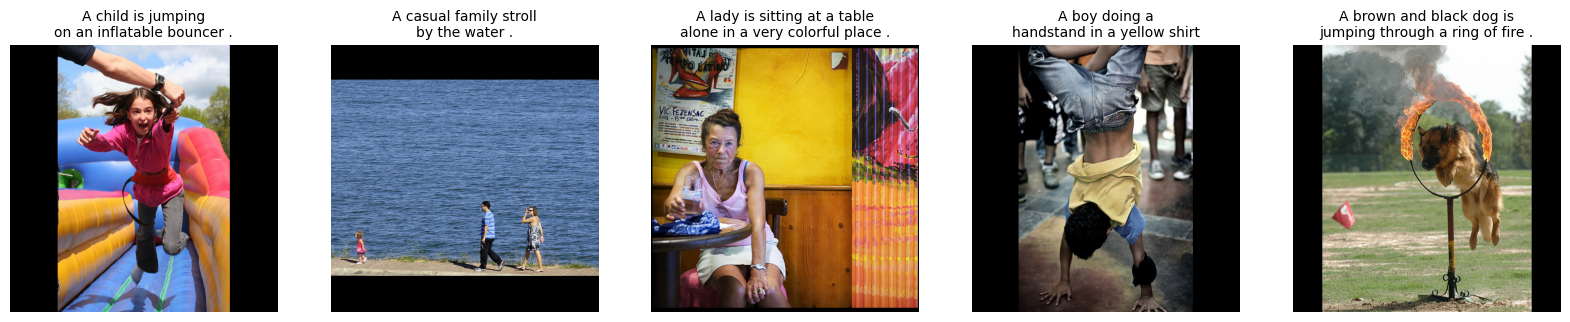

In [8]:
# -------------------------------------------------------------------------
# Visualise both the images & text present in the dataset
# -------------------------------------------------------------------------
def normalize_image(img_path, target_size=(512, 512)):
    """Given an image, resize image with black padding, where original image is in center of padded image"""

    # ---------------------------------------------------------------------
    # Read image and calculate new image dimensions to maintain aspect ratio
    # Resize the original image that at least 1 dimension equal target, keep ratio
    # ---------------------------------------------------------------------
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    (h, w) = img.shape[:2]
    
    if h>w:
        h = target_size[1]
        w = int(target_size[1]*w/h)
    else:
        w = target_size[0]
        h = int(target_size[0]*h/w)
    
    img = cv2.resize(img, (w, h))

    # ---------------------------------------------------------------------
    # Calculate the padding required
    # ---------------------------------------------------------------------
    pad_top = int((target_size[1] - h) // 2)
    pad_bottom = target_size[1] - h - pad_top
    pad_left = int((target_size[0] - w) // 2)
    pad_right = target_size[0] - w - pad_left

    # ---------------------------------------------------------------------
    # Create a black border with the calculated padding dimensions
    #
    # ---------------------------------------------------------------------
    border = cv2.copyMakeBorder(img, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=[0, 0, 0])

    return border

def add_line(text):
    """Split str to 2 lines"""
    text = text.strip()
    words = text.split(' ')
    num_words = len(words)
    split_index = num_words//2
    text = ' '.join(words[:split_index]) + '\n' + ' '.join(words[split_index:])
    
    return text


def visualize_images_and_captions(img_path_lst, caption_path, num_samples=5):
    """
    Function to visualize images and their corresponding captions from the dataframe.
    
    Parameters:
        - img_path_lst: `List[str]`, list of image path
        - caption_path: path of caption text file
        - num_samples (int): The number of samples to display.
    """
    plt.figure(figsize=(20, 10))

    sample_path_lst = np.random.choice(img_path_lst, num_samples)
    
    for sample_index, sample_path in enumerate(sample_path_lst):
        # -----------------------------------------------------------------
        # Read the image and resize with black padding
        sample_img = normalize_image(sample_path)
        
        # -----------------------------------------------------------------
        # Read coressponding caption
        with open(caption_path, 'r', encoding='utf-8') as caption_file:
            data = caption_file.readlines()

        for line in data:
            img_name, caption = line.split(',', maxsplit=1)
            if os.path.basename(sample_path) == img_name:
                sample_caption = caption
                break
        
        sample_caption = add_line(sample_caption)

        # -----------------------------------------------------------------
        # Draw image with caption
        plt.subplot(1, num_samples, sample_index+1)
        plt.imshow(sample_img)
        plt.title(sample_caption, fontsize=10)
        plt.axis('off')

    plt.show()

visualize_images_and_captions(img_path_lst, caption_path, num_samples=5)

### 3. Create the DataFrame

Create a dataframe which summarizes the image, path & captions as a dataframe

Each image id has 5 captions associated with it therefore the total dataset should have 40455 samples.

In [9]:
# -------------------------------------------------------------------------
# Split the document into lines
# Initialize lists to hold image IDs, paths, and captions
# -------------------------------------------------------------------------
lines = doc.strip().split('\n')
all_img_id = []
all_img_vector = []
annotations = []

# -------------------------------------------------------------------------
# Process each line
# -------------------------------------------------------------------------
for line in lines[1:]:
    parts = line.split(',')
    image_id = parts[0]
    caption = ','.join(parts[1:]).strip()
    
    all_img_id.append(image_id)
    all_img_vector.append(os.path.join(image_dir, image_id))
    annotations.append(caption)

# -------------------------------------------------------------------------
# Create a DataFrame
# -------------------------------------------------------------------------
df = pd.DataFrame(list(zip(all_img_id, all_img_vector, annotations)), columns=['ID','Path', 'Captions'])
print(len(df))
print(df.head())

40455
                          ID                                             Path  \
0  1000268201_693b08cb0e.jpg  data/Flickr_8k/Images/1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg  data/Flickr_8k/Images/1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg  data/Flickr_8k/Images/1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg  data/Flickr_8k/Images/1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg  data/Flickr_8k/Images/1000268201_693b08cb0e.jpg   

                                            Captions  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  


### 4. Create a list which contains all the captions & path

In [10]:
# -------------------------------------------------------------------------
# Add <start> and <end> tokens to captions
# Create a list with all image paths
# -------------------------------------------------------------------------
annotations = ['<start> ' + caption + ' <end>' for caption in annotations]
all_img_path = df['Path'].tolist()

print("Total captions present in the dataset: " + str(len(annotations)))
print("Total images present in the dataset: " + str(len(all_img_path)))

Total captions present in the dataset: 40455
Total images present in the dataset: 40455


### 5. Visualise the top 30 occuring words in the captions

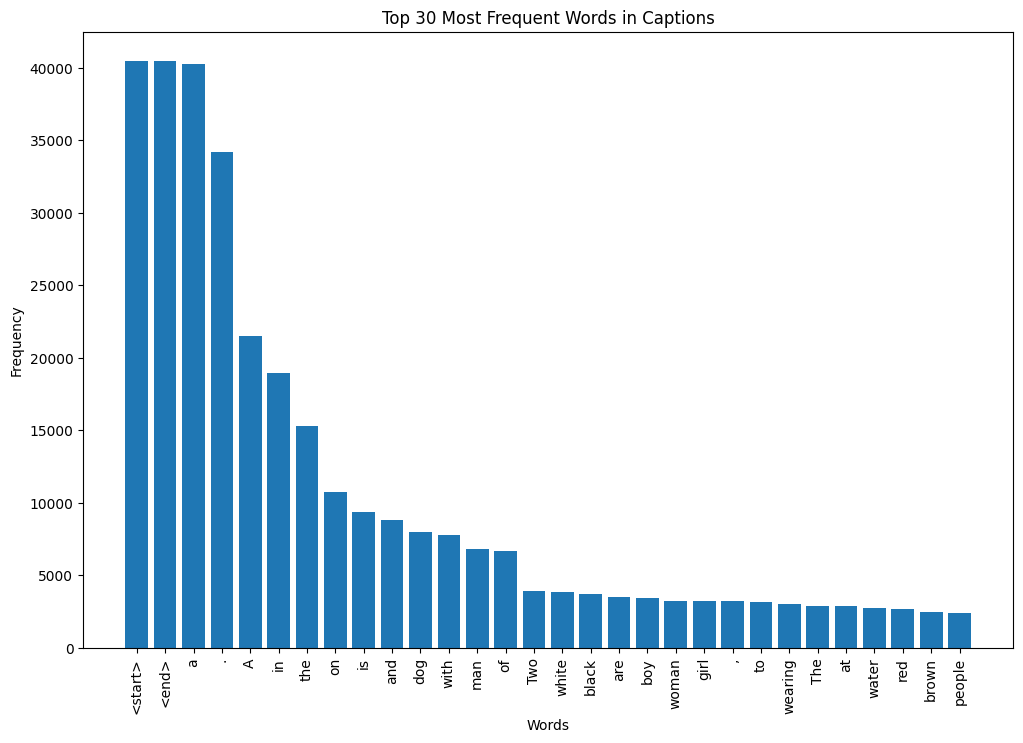

In [11]:
# -------------------------------------------------------------------------
# Create a vocabulary
# Create a counter for the vocabulary
# Get 30 top occuring words
# -------------------------------------------------------------------------
# vocabulary = [word for caption in annotations for word in caption.split() if word not in ['<start>', '<end>', ".\""] and word not in '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n']
vocabulary = [word for caption in annotations for word in caption.split()]
val_count = Counter(vocabulary)
top_words = val_count.most_common(30)
words, counts = zip(*top_words)

# -------------------------------------------------------------------------
# Visualize the top 30 occurring words in the captions
# NOTE: words not in [<start>, <end>, ."] and '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
# -------------------------------------------------------------------------
plt.figure(figsize=(12, 8))
plt.bar(words, counts)
plt.title('Top 30 Most Frequent Words in Captions')
plt.xticks(rotation=90)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

## II. Pre-Processing the captions
1. Create the tokenized vectors by tokenizing the captions fore ex :split them using spaces & other filters. 
This gives us a vocabulary of all of the unique words in the data. Keep the total vocaublary to top 5,000 words for saving memory.

2. Replace all other words with the unknown token "UNK" .

3. Create word-to-index and index-to-word mappings.

4. Pad all sequences to be the same length as the longest one.

### 1. Create the tokenizer

<ul>
    <li> Including Delimiters:
    <ol>
        <li> Pros:
        <ul>
            <li> Explicit Separation: Delimiters can explicitly mark the boundaries between different entities or concepts identified in the image. This can be helpful for tasks like image captioning, where you want to identify and describe distinct objects or scenes in the image.
            <li> Structured Output: Including delimiters can lead to a more structured output, which might be easier to parse or interpret depending on the downstream application.
            <li> Task-Specific Delimiters: You can define custom delimiters relevant to your task. For example, you could use a delimiter to separate different actions happening in the image.
        </ul>
        <li> Cons:
        <ul>
            <li> Unnecessary Complexity: If the task doesn't require explicit separation of entities, including delimiters might add unnecessary complexity to the model and potentially hinder its performance.
            <li> Learning Delimiters: The model needs to learn not only to identify the relevant information from the image but also to correctly place the delimiters in the output text. This can be an additional learning burden.
        </ul>
    </ol>
    <li> Not Including Delimiters:
    <ol> 
        <li> Pros:
        <ul>
            <li> Simpler Model: The model only needs to focus on generating the natural language description of the image without worrying about delimiters. This can potentially lead to a simpler and more efficient model.
            <li> Natural Language Flow: The output text might read more naturally without delimiters interrupting the flow of the sentence.
        </ul> 
        <li> Cons:
        <ul>
            <li> Ambiguity: For tasks where identifying and separating distinct entities is important, the lack of delimiters might lead to ambiguity in the output text.
        </ul>


In [12]:
# -------------------------------------------------------------------------
# Create the tokenizer and fit on texts, with vocabulary limitation is 5000,
# and replace other words with "UNK", lower all words for simplicity and more words in dictionary
# -------------------------------------------------------------------------
tokenizer = Tokenizer(
                        num_words=5000,
                        oov_token='UNK',
                        lower=True,
                        filters='!"#$%&()*+.,-/:;=?@[\\]^_`{|}~ '
                     )
tokenizer.fit_on_texts(annotations)

In [13]:
# -------------------------------------------------------------------------
# NOTE: Tokenizer.word_index code will bypass the num_words, but in text_to_sequences
# methods will have this limit
# https://stackoverflow.com/questions/64206715/tensorflow-tokeniser-the-maximum-number-of-words-to-keep
# -------------------------------------------------------------------------
vocab_size = len(tokenizer.word_index) + 1  # Adding 1 because of reserved 0 index
print(f"Vocabulary Size: {vocab_size}")

Vocabulary Size: 8497


### 2. Word-to-index and index-to word mappings

In [14]:
# -------------------------------------------------------------------------
# Create word-to-index and index-to-word mappings
# -------------------------------------------------------------------------
word_to_index = tokenizer.word_index
index_to_word = {v: k for k, v in word_to_index.items()}

print(f"Word to Index mapping (first 10): {list(word_to_index.items())[:10]}")
print(f"Index to Word mapping (first 10): {list(index_to_word.items())[:10]}")

Word to Index mapping (first 10): [('UNK', 1), ('a', 2), ('<start>', 3), ('<end>', 4), ('in', 5), ('the', 6), ('on', 7), ('is', 8), ('and', 9), ('dog', 10)]
Index to Word mapping (first 10): [(1, 'UNK'), (2, 'a'), (3, '<start>'), (4, '<end>'), (5, 'in'), (6, 'the'), (7, 'on'), (8, 'is'), (9, 'and'), (10, 'dog')]


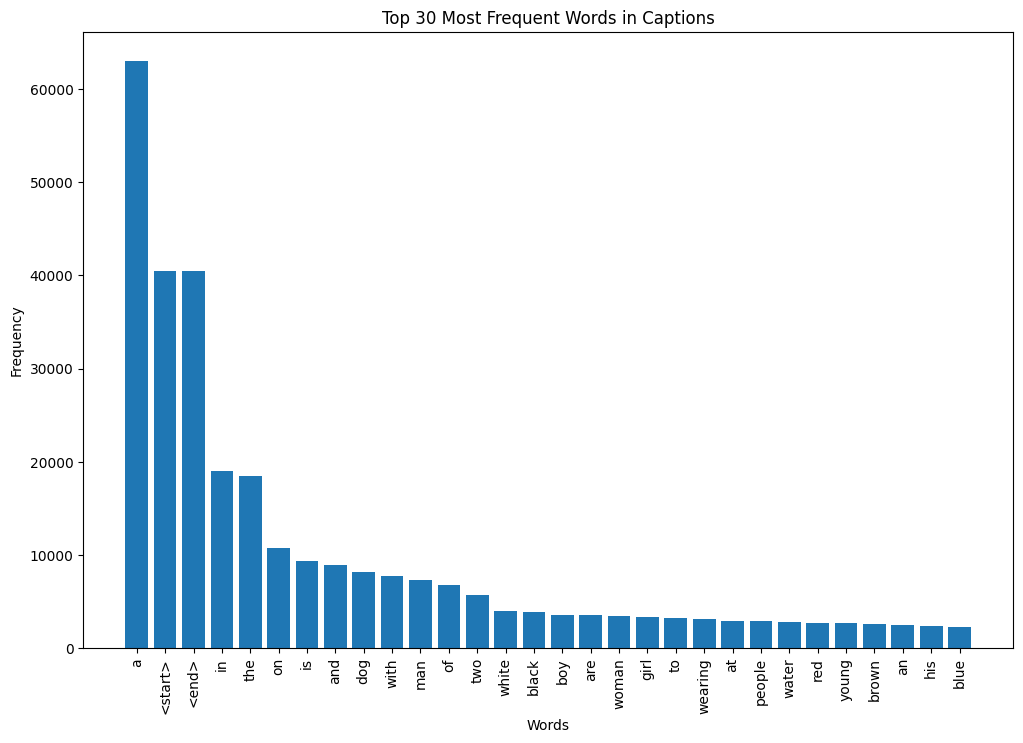

In [15]:
# -------------------------------------------------------------------------
# Create a word count of tokenizer to visulize the Top 30 occuring words after text processing
# -------------------------------------------------------------------------
word_counts = tokenizer.word_counts
word_counts = dict(sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:30])

# Visualize the top 30 words
words, counts = zip(*word_counts.items())

plt.figure(figsize=(12, 8))
plt.bar(words, counts)
plt.title('Top 30 Most Frequent Words in Captions')
plt.xticks(rotation=90)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

### 3. Pad all sequences to be the same length as the longest one.

In [16]:
# -------------------------------------------------------------------------
# Convert the text to sequences
# Pad sequences
# -------------------------------------------------------------------------
sequences = tokenizer.texts_to_sequences(annotations)

max_length = max(len(seq) for seq in sequences)
cap_vector = pad_sequences(sequences, maxlen=max_length, padding='post')

print(f"Max length of sequences: {max_length}")
print("The shape of Caption vector is :" + str(cap_vector.shape))

Max length of sequences: 39
The shape of Caption vector is :(40455, 39)


## III. Pre-processing the images

1.Resize them into the shape of (299, 299)

3.Normalize the image within the range of -1 to 1, such that it is in correct format for InceptionV3. 

### FAQs on how to resize the images::
* Since you have a list which contains all the image path, you need to first convert them to a dataset using <i>tf.data.Dataset.from_tensor_slices</i>. Once you have created a dataset consisting of image paths, you need to apply a function to the dataset which will apply the necessary preprocessing to each image. 
* This function should resize them and also should do the necessary preprocessing that it is in correct format for InceptionV3.


In [17]:
# -------------------------------------------------------------------------
# Create the dataset consisting of image paths
# -------------------------------------------------------------------------
image_path_dataset = tf.data.Dataset.from_tensor_slices(all_img_path)

2024-06-29 23:03:15.076507: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-29 23:03:15.463183: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-29 23:03:15.463415: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [18]:
# -------------------------------------------------------------------------
# Preprocessing image function
# -------------------------------------------------------------------------
def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (299, 299))
    img = (img / 127.5) - 1.0
    return img, image_path

In [19]:
# -------------------------------------------------------------------------
# Apply the preprocessing function to the dataset
# -------------------------------------------------------------------------
image_dataset = image_path_dataset.map(load_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)

# -------------------------------------------------------------------------
# Check a few examples to ensure the images are loaded and preprocessed correctly
# -------------------------------------------------------------------------
for img, path in image_dataset.take(3):
    print(f"Image shape: {img.shape}, Image path: {path.numpy()}")

Image shape: (299, 299, 3), Image path: b'data/Flickr_8k/Images/1000268201_693b08cb0e.jpg'
Image shape: (299, 299, 3), Image path: b'data/Flickr_8k/Images/1000268201_693b08cb0e.jpg'
Image shape: (299, 299, 3), Image path: b'data/Flickr_8k/Images/1000268201_693b08cb0e.jpg'


## Load the pretrained Imagenet weights of Inception net V3

1.To save the memory(RAM) from getting exhausted, extract the features of the images using the last layer of pre-trained model. Including this as part of training will lead to higher computational time.

2.The shape of the output of this layer is 8x8x2048. 

3.Use a function to extract the features of each image in the train & test dataset such that the shape of each image should be (batch_size, 8*8, 2048)



### 1. Load the Pretrained InceptionV3 Model

In [20]:
# -------------------------------------------------------------------------
# Load the InceptionV3 model with ImageNet weights, excluding the top fully connected layer
# -------------------------------------------------------------------------
image_model = InceptionV3(include_top=False, weights='imagenet')

# -------------------------------------------------------------------------
# Define the new input and output layers
# -------------------------------------------------------------------------
new_input = image_model.input
hidden_layer = image_model.layers[-1].output

# -------------------------------------------------------------------------
# Create a new model that will output the features from the last convolutional layer
# -------------------------------------------------------------------------
image_features_extract_model = Model(inputs=new_input, outputs=hidden_layer)

# -------------------------------------------------------------------------
# Summary of the model
# -------------------------------------------------------------------------
image_features_extract_model.summary()

87910968/87910968 [==============================] - 7s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, None, None, 3)]      0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, None, None, 32)       864       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, None, None, 32)       96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     

### 2. Extract Features Using the Pretrained Model

In [21]:
def extract_image_features(image_dataset):
    """
    Function to extract features from images using the InceptionV3 model.
    
    Args:
        - image_dataset (tf.data.Dataset): The dataset containing images.
    
    Returns:
        - features (dict): A dictionary containing image paths as keys and extracted features as values.

    NOTE: Cause we only have around 8k unique images over 40k caption, so we will check if image features exists or not before create it
    """
    features = {}
    
    print("Starting extract features")

    for img, path in tqdm(image_dataset):
        # -----------------------------------------------------------------
        # Check if this feature is exists or not
        # -----------------------------------------------------------------
        path_id = path.numpy().decode('utf-8')
        if path_id in features:
            continue

        # -----------------------------------------------------------------
        # Expand dimensions to include the batch size
        # Extract features
        # Reshape features to (8*8, 2048)
        # Convert to numpy array
        # -----------------------------------------------------------------
        img_batch = tf.expand_dims(img, axis=0)
        img_features = image_features_extract_model(img_batch)
        img_features = tf.reshape(img_features, (img_features.shape[0], -1, img_features.shape[-1]))
        img_features_np = img_features.numpy()
        
        # -----------------------------------------------------------------
        # Store the features in the dictionary
        # -----------------------------------------------------------------
        features[path.numpy().decode('utf-8')] = img_features_np
    
    print("Done extract features")

    return features

# Extract features from the image dataset
image_features = extract_image_features(image_dataset)

# Print a sample feature
sample_path = list(image_features.keys())[0]
print(f"Sample image path: {sample_path}")
print(f"Sample image features shape: {image_features[sample_path].shape}")

Starting extract features


100%|██████████| 40455/40455 [20:32<00:00, 32.82it/s]

Done extract features
Sample image path: data/Flickr_8k/Images/1000268201_693b08cb0e.jpg
Sample image features shape: (1, 64, 2048)


### 3. Store the Extracted Features

In [22]:
# -------------------------------------------------------------------------
# Save features to disk
# -------------------------------------------------------------------------
for path, features in image_features.items():
    # ---------------------------------------------------------------------
    # Extract image ID from the path
    image_id = os.path.basename(path).split('.')[0]
    
    # ---------------------------------------------------------------------
    # Save features as .npy file
    np.save(os.path.join(features_dir, f'{image_id}.npy'), features)


### FAQs on how to store the features:
* You can store the features using a dictionary with the path as the key and values as the feature extracted by the inception net v3 model OR
* You can store using numpy(np.save) to store the resulting vector.

## Dataset creation
1.Apply train_test_split on both image path & captions to create the train & test list. Create the train-test spliit using 80-20 ratio & random state = 42

2.Create a function which maps the image path to their feature. 

3.Create a builder function to create train & test dataset & apply the function created earlier to transform the dataset

2.Make sure you have done Shuffle and batch while building the dataset

3.The shape of each image in the dataset after building should be (batch_size, 8*8, 2048)

4.The shape of each caption in the dataset after building should be(batch_size, max_len)


### 1. Apply Train-Test Split

In [23]:
# -------------------------------------------------------------------------
# Split the data into training and testing sets
# -------------------------------------------------------------------------
path_train, path_test, cap_train, cap_test = train_test_split(df['Path'].tolist(), annotations, test_size=0.2, random_state=42)

In [24]:
print("Training data for images: " + str(len(path_train)))
print("Testing data for images: " + str(len(path_test)))
print("Training data for Captions: " + str(len(cap_train)))
print("Testing data for Captions: " + str(len(cap_test)))

Training data for images: 32364
Testing data for images: 8091
Training data for Captions: 32364
Testing data for Captions: 8091


### 2. Create a Function to Map Image Path to Feature

In [25]:
def map_func(img_path, cap):
    """
    Function to map the image path to its feature and return the feature and caption.
    
    Parameters:
    img_path (tf.Tensor): The path of the image.
    cap (tf.Tensor): The caption for the image.
    
    Returns:
    img_tensor (numpy.array): The extracted features from the image.
    cap_tensor (numpy.array): The processed caption as a sequence of integers.
    """
    # Decode and process the image path (assuming it's a string tensor)
    img_path_str = img_path.decode('utf-8')
    image_id = os.path.basename(img_path_str).split('.')[0]
    
    # Load the image features from the .npy file
    img_tensor = np.float32(np.load(os.path.join(features_dir, f'{image_id}.npy')).reshape(64,2048))
    
    # Convert caption to sequence of integers
    sequences = tokenizer.texts_to_sequences([cap.decode('utf-8')])
    cap_tensor = pad_sequences(sequences, maxlen=max_length, padding='post')[0]  # Take the first (and only) sequence

    return img_tensor, cap_tensor

### 3. Create a Builder Function for the Dataset

In [26]:
def gen_dataset(img_paths, caps):
    """
    Function to generate a dataset with the given image paths and captions.
    
    Parameters:
    img_paths (list): List of image paths.
    caps (list): List of captions.
    
    Returns:
    dataset (tf.data.Dataset): The transformed dataset.
    """
    # Create a TensorFlow dataset from the image paths and captions
    dataset = tf.data.Dataset.from_tensor_slices((img_paths, caps))
    
    # Map the dataset using the map_func
    dataset = dataset.map(lambda img, cap: tf.numpy_function(map_func, [img, cap], [tf.float32, tf.int32]),
                          num_parallel_calls=tf.data.experimental.AUTOTUNE)
    
    # Shuffle, batch, and prefetch the dataset
    dataset = dataset.shuffle(buffer_size=len(img_paths)).batch(batch_size).prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    
    return dataset

# Generate the training and testing datasets
train_dataset = gen_dataset(path_train, cap_train)
test_dataset = gen_dataset(path_test, cap_test)

# Fetch a sample batch to check the shapes
sample_img_batch, sample_cap_batch = next(iter(train_dataset))
print(sample_img_batch.shape)  # (batch_size, 8*8, 2048)
print(sample_cap_batch.shape)  # (batch_size, max_len)

2024-06-29 23:28:22.413865: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 15397 of 32364
2024-06-29 23:28:37.574250: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 27673 of 32364
2024-06-29 23:28:54.934156: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 30172 of 32364
2024-06-29 23:29:03.770674: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


(32, 64, 2048)
(32, 39)


### FAQs on how to load the features:
* You can load the features using the dictionary created earlier OR
* You can store using numpy(np.load) to load the feature vector.

## BASE MODEL building, training, optimizing and evaluating

### 1. Model Building
<ul>
    <li> Set the parameters
    <li> Build the Encoder, Attention model & Decoder
</ul>

In [27]:
embedding_dim = 256 
units = 512
vocab_size = 5001  # Vocabulary size including padding token
train_num_steps = len(path_train) // batch_size
test_num_steps = len(path_test) // batch_size

#### 1.1. Encoder

In [28]:
class Encoder(Model):
    def __init__(self, embed_dim):
        super(Encoder, self).__init__()
        self.dense = Dense(embed_dim, activation='relu')
        
    def call(self, features):
        features = self.dense(features)
        return features

In [29]:
encoder=Encoder(embedding_dim)

#### 1.2. Attention model

In [30]:
class Attention_model(Model):
    def __init__(self, units):
        super(Attention_model, self).__init__()
        self.W1 = Dense(units)
        self.W2 = Dense(units)
        self.V = Dense(1)
        self.units = units

    def call(self, features, hidden):
        hidden_with_time_axis = tf.expand_dims(hidden, 1)
        score = tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis))
        attention_weights = tf.nn.softmax(self.V(score), axis=1)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)
        
        return context_vector, attention_weights

In [31]:
class BahdanauAttention(Model):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = Dense(units)
        self.W2 = Dense(units)
        self.V = Dense(1)

    def call(self, features, hidden):
        # features shape: (batch_size, 8*8, units)
        # hidden shape: (batch_size, units)
        
        hidden_with_time_axis = tf.expand_dims(hidden, 1)
        score = tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis))
        
        # Calculate attention weights
        attention_weights = tf.nn.softmax(self.V(score), axis=1)
        
        # Calculate context vector
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights

#### 1.3. Decoder

In [32]:
class Decoder(Model):
    def __init__(self, embed_dim, units, vocab_size):
        super(Decoder, self).__init__()
        self.units = units
        self.attention = Attention_model(units)
        self.embed = Embedding(vocab_size, embed_dim)
        self.gru = GRU(self.units, return_sequences=True, return_state=True, recurrent_initializer='glorot_uniform')
        self.d1 = Dense(self.units)
        self.d2 = Dense(vocab_size)

    def call(self, x, features, hidden):
        context_vector, attention_weights = self.attention(features, hidden)
        embed = self.embed(x)
        embed = tf.concat([tf.expand_dims(context_vector, 1), embed], axis=-1)
        output, state = self.gru(embed)
        output = self.d1(output)
        output = tf.reshape(output, (-1, output.shape[2]))
        output = self.d2(output)
        
        return output, state, attention_weights

    def init_state(self, batch_size):
        return tf.zeros((batch_size, self.units))

In [33]:
decoder=Decoder(embedding_dim, units, vocab_size)

#### 1.4. Test feedfoward

In [34]:
features=encoder(sample_img_batch)

hidden = decoder.init_state(batch_size=sample_cap_batch.shape[0])
dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * sample_cap_batch.shape[0], 1)

predictions, hidden_out, attention_weights= decoder(dec_input, features, hidden)
print('Feature shape from Encoder: {}'.format(features.shape)) #(batch, 8*8, embed_dim)
print('Predcitions shape from Decoder: {}'.format(predictions.shape)) #(batch,vocab_size)
print('Attention weights shape from Decoder: {}'.format(attention_weights.shape)) #(batch, 8*8, embed_dim)

Feature shape from Encoder: (32, 64, 256)
Predcitions shape from Decoder: (32, 5001)
Attention weights shape from Decoder: (32, 64, 1)


### 2. Model training & optimization
<ol>
    <li> Set the optimizer & loss object
    <li> Create your checkpoint path
    <li> Create your training & testing step functions
    <li> Create your loss function for the test dataset
</ol>


#### 2.1. Set the optimizer & loss object

In [35]:
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

#### 2.2. Create your checkpoint path

In [36]:
checkpoint_path = "./training_checkpoints"
ckpt = tf.train.Checkpoint(encoder=encoder,
                           decoder=decoder,
                           optimizer=optimizer)
ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)
start_epoch = 0

if ckpt_manager.latest_checkpoint:
    start_epoch = int(ckpt_manager.latest_checkpoint.split('-')[-1])


#### 2.3 Define the loss function for the test dataset

In [37]:
def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)

    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask

    return tf.reduce_mean(loss_)


#### 2.4. Create your training & testing step functions

In [38]:
# -------------------------------------------------------------------------
# For base model
# -------------------------------------------------------------------------
@tf.function
def train_step(img_tensor, target):
    loss = 0
    hidden = decoder.init_state(batch_size=target.shape[0])
    dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)
    
    with tf.GradientTape() as tape:
        features = encoder(img_tensor)
        for i in range(1, target.shape[1]):
            predictions, hidden, _ = decoder(dec_input, features, hidden)
            loss += loss_function(target[:, i], predictions)
            dec_input = tf.expand_dims(target[:, i], 1)
        
    total_loss = (loss / int(target.shape[1]))
    trainable_variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, trainable_variables)
    optimizer.apply_gradients(zip(gradients, trainable_variables))
    
    return loss, total_loss

@tf.function
def test_step(img_tensor, target):
    loss = 0
    hidden = decoder.init_state(batch_size=target.shape[0])
    dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)
    
    features = encoder(img_tensor)
    for i in range(1, target.shape[1]):
        predictions, hidden, _ = decoder(dec_input, features, hidden)
        loss += loss_function(target[:, i], predictions)
        predicted_id = tf.argmax(predictions, axis=1)
        dec_input = tf.expand_dims(predicted_id, 1)
    
    avg_loss = (loss / int(target.shape[1]))
    
    return loss, avg_loss

def test_loss_cal(test_dataset):
    total_loss = 0
    num_batches = 0
    
    for (batch, (img_tensor, target)) in enumerate(test_dataset):
        batch_loss, t_loss = test_step(img_tensor, target)
        total_loss += t_loss
        num_batches += 1
        
    avg_test_loss = total_loss / num_batches
    return avg_test_loss

#### 2.5.  Model Training Loop

2024-06-29 23:31:29.935351: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 2310 of 32364
2024-06-29 23:31:49.940924: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 9938 of 32364
2024-06-29 23:32:09.992227: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 30291 of 32364
2024-06-29 23:32:13.400777: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.
2024-06-29 23:32:51.120639: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7569882e79b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-06-29 23:32:51.120677: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2024-06-29 23:32:51.209438: I

Epoch 1 Batch 0 Loss 2.6215
Epoch 1 Batch 100 Loss 1.6154
Epoch 1 Batch 200 Loss 1.3027
Epoch 1 Batch 300 Loss 1.2007
Epoch 1 Batch 400 Loss 1.0595
Epoch 1 Batch 500 Loss 1.1565
Epoch 1 Batch 600 Loss 1.0519
Epoch 1 Batch 700 Loss 1.1055
Epoch 1 Batch 800 Loss 0.9291
Epoch 1 Batch 900 Loss 1.0270
Epoch 1 Batch 1000 Loss 0.9901


2024-06-29 23:34:50.015779: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:12: Filling up shuffle buffer (this may take a while): 5120 of 8091
2024-06-29 23:34:54.380958: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


Epoch 1 Train Loss 1.1980 Test Loss 1.8810
Time taken for 1 epoch 258.73 sec



2024-06-29 23:35:48.930819: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 9528 of 32364
2024-06-29 23:35:58.931404: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 22815 of 32364
2024-06-29 23:36:08.744319: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


...

Epoch 9 Batch 0 Loss 0.5086
Epoch 9 Batch 100 Loss 0.6093
Epoch 9 Batch 200 Loss 0.6234
Epoch 9 Batch 300 Loss 0.6035
Epoch 9 Batch 400 Loss 0.5959
Epoch 9 Batch 500 Loss 0.5643
Epoch 9 Batch 600 Loss 0.6792
Epoch 9 Batch 700 Loss 0.5732
Epoch 9 Batch 800 Loss 0.5987
Epoch 9 Batch 900 Loss 0.6825
Epoch 9 Batch 1000 Loss 0.6060


2024-06-30 00:01:57.964671: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:12: Filling up shuffle buffer (this may take a while): 609 of 8091
2024-06-30 00:02:07.965133: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:12: Filling up shuffle buffer (this may take a while): 1228 of 8091
2024-06-30 00:02:17.969417: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:12: Filling up shuffle buffer (this may take a while): 2081 of 8091
2024-06-30 00:02:37.970195: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:12: Filling up shuffle buffer (this may take a while): 4547 of 8091
2024-06-30 00:02:57.057259: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


Epoch 9 Train Loss 0.5968 Test Loss 2.0418
Time taken for 1 epoch 366.25 sec



2024-06-30 00:04:19.896548: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 2534 of 32364
2024-06-30 00:04:29.899017: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 6317 of 32364
2024-06-30 00:04:49.897631: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 17532 of 32364
2024-06-30 00:05:09.894203: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 31105 of 32364
2024-06-30 00:05:11.780218: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


Epoch 10 Batch 0 Loss 0.5549
Epoch 10 Batch 100 Loss 0.4520
Epoch 10 Batch 200 Loss 0.5256
Epoch 10 Batch 300 Loss 0.5947
Epoch 10 Batch 400 Loss 0.5133
Epoch 10 Batch 500 Loss 0.6069
Epoch 10 Batch 600 Loss 0.5847
Epoch 10 Batch 700 Loss 0.5569
Epoch 10 Batch 800 Loss 0.6002
Epoch 10 Batch 900 Loss 0.5463
Epoch 10 Batch 1000 Loss 0.4969
Epoch 10 Train Loss 0.5642 Test Loss 2.0997
Time taken for 1 epoch 220.50 sec



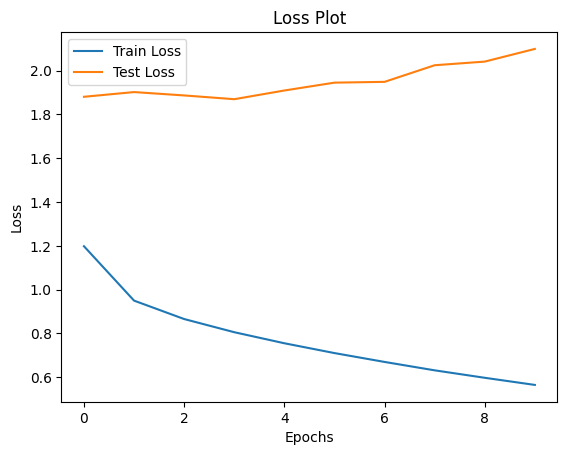

In [39]:
# -------------------------------------------------------------------------
# Training base model
# -------------------------------------------------------------------------
loss_plot = []
test_loss_plot = []
EPOCHS = 10

best_test_loss = 100

for epoch in range(start_epoch, EPOCHS):
    start = time.time()
    total_loss = 0
    
    for (batch, (img_tensor, target)) in enumerate(train_dataset):
        batch_loss, t_loss = train_step(img_tensor, target)
        total_loss += t_loss
        
        if batch % 100 == 0:
            print(f'Epoch {epoch+1} Batch {batch} Loss {batch_loss.numpy() / int(target.shape[1]):.4f}')
    
    avg_train_loss = total_loss / train_num_steps
    loss_plot.append(avg_train_loss)
    
    test_loss = test_loss_cal(test_dataset)
    test_loss_plot.append(test_loss)
    
    print(f'Epoch {epoch+1} Train Loss {avg_train_loss:.4f} Test Loss {test_loss:.4f}')
    print(f'Time taken for 1 epoch {time.time() - start:.2f} sec\n')
    
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        ckpt_manager.save()
    
plt.plot(loss_plot, label='Train Loss')
plt.plot(test_loss_plot, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Plot')
plt.legend()
plt.show()

#### 2.6. Load model from lastest (best) checkpoint

In [40]:
latest_checkpoint = ckpt_manager.latest_checkpoint

if latest_checkpoint:
    print("Loading weights from the best checkpoint:", latest_checkpoint)
    ckpt.restore(latest_checkpoint)
else:
    print("No checkpoint found. Starting model from scratch.")

Loading weights from the best checkpoint: ./training_checkpoints/ckpt-2


#### NOTE: 
* Since there is a difference between the train & test steps ( Presence of teacher forcing), you may observe that the train loss is decreasing while your test loss is not. 
* This doesn't mean that the model is overfitting, as we can't compare the train & test results here, as both approach is different.
* Also, if you want to achieve better results you can run it more epochs, but the intent of this capstone is to give you an idea on how to integrate attention mechanism with E-D architecture for images. The intent is not to create the state of art model. 

### 3. Model Evaluation
<ol>
    <li> Define your evaluation function using greedy search
    <li> Define your evaluation function using beam search
    <li> Define evaluation function using perplexity
    <li> Test it on a sample data using BLEU score
</ol>

#### 3.1. Greedy Search

In [41]:
def greedy_evaluate(image_path, max_length=max_length, attention_features_shape=64):
    attention_plot = np.zeros((max_length, attention_features_shape))

    hidden = decoder.init_state(batch_size=1)

    # ---------------------------------------------------------------------
    # Preprocess the input image to the desired format before extracting features
    # ---------------------------------------------------------------------
    temp_input = tf.expand_dims(load_image(image_path)[0], 0)
    img_tensor_val = image_features_extract_model(temp_input)
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))

    # ---------------------------------------------------------------------
    # Encode image to feature
    # ---------------------------------------------------------------------
    features = encoder(img_tensor_val)

    # ---------------------------------------------------------------------
    # Init parameters
    # Loop to find words from begin of start
    # ---------------------------------------------------------------------
    dec_input = tf.expand_dims([tokenizer.word_index['<start>']], 0)
    result = []

    for i in range(max_length):
        predictions, hidden, attention_weights = decoder(dec_input, features, hidden)

        predicted_id = tf.argmax(predictions, axis=1).numpy()[0]
        if tokenizer.index_word[predicted_id] == '<end>':
            break

        attention_plot[i] = tf.reshape(attention_weights, (-1,)).numpy()
        result.append(tokenizer.index_word[predicted_id])

        if tokenizer.index_word[predicted_id] == '<end>':
            return result, attention_plot

        dec_input = tf.expand_dims([predicted_id], 0)

    attention_plot = attention_plot[:len(result), :]
    return result, attention_plot

In [42]:
cap_test[2]

'<start> A man in shorts is standing on a rock looking out at the view from the hilltop . <end>'

In [43]:
greedy_evaluate(path_test[2])[0]

['a', 'man', 'is', 'climbing', 'a', 'rock', 'face']

#### 3.2. Beam Search(optional)

In [109]:
def beam_evaluate(image, beam_index=3):
    start_token = [tokenizer.word_index['<start>']]
    end_token = tokenizer.word_index['<end>']
    
    # Preprocess the input image
    temp_input = tf.expand_dims(load_image(image)[0], 0)
    img_tensor_val = image_features_extract_model(temp_input)
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))

    features = encoder(img_tensor_val)

    # Initialize beam search
    beam_final = []
    beam = [{'seq': start_token, 'score': 0.0, 'hidden': decoder.init_state(batch_size=1)}]

    for index in range(max_length-1): # already have <start> as first word
        candidates = []

        for s in beam:
            dec_input = tf.expand_dims([s['seq'][-1]], 0)
            predictions, hidden, _ = decoder(dec_input, features, s['hidden'])
            top_preds = tf.math.top_k(predictions, k=beam_index)
            
            # predicted_id_max = tf.argmax(predictions, axis=1).numpy()[0]
            # if tokenizer.index_word[predicted_id_max] == '<end>':
            #     for b in beam:
            #         print(f"Seq: {[tokenizer.index_word[i] for i in b['seq']]}, Score: {b['score']}")
            #         print(tokenizer.index_word[predicted_id_max], len(candidate_seq))

            for i in range(beam_index):
                pred_id = top_preds.indices.numpy()[0][i]
                score = s['score']*len(s['seq']) + top_preds.values.numpy()[0][i]
                score /= (len(s['seq'])+1)
                candidate_seq = s['seq'] + [pred_id]

                if tokenizer.index_word[pred_id] == "<end>":
                    beam_final.append({'seq': candidate_seq, 'score': score, 'hidden': hidden})
                    # candidates.append({'seq': candidate_seq, 'score': score, 'hidden': hidden})
                elif len(candidate_seq) < max_length:
                    candidates.append({'seq': candidate_seq, 'score': score, 'hidden': hidden})
                else: # skip sentences without <end>
                    continue

        beam = sorted(candidates, key=lambda x: x['score'], reverse=True)[:beam_index]

        # # Debugging
        # print(f"Index {index}, Beam Size: {len(beam)}")
        

        # for b in beam:
        #     print(f"Seq: {[tokenizer.index_word[i] for i in b['seq']]}, Score: {b['score']}")

        # Check if all sequences have ended
        # end_flag = True
        # for s in beam:
        #     if s['seq'][-1] != end_token:
        #         end_flag = False
        #         break
        # if end_flag:
        #     break

    if not beam_final:
        print("Beam is empty. Returning default caption.")
        return "<empty>"

    best_seq = beam_final[0]['seq']
    pred_caption = [tokenizer.index_word[i] for i in best_seq if i != 0]
    pred_caption = ' '.join(pred_caption[1:-1])  # Remove start and end tokens
    
    return pred_caption

# Test the updated beam_evaluate function
print(beam_evaluate(path_test[2]))


a man is climbing a rock


In [110]:
cap_test[2]

'<start> A man in shorts is standing on a rock looking out at the view from the hilltop . <end>'

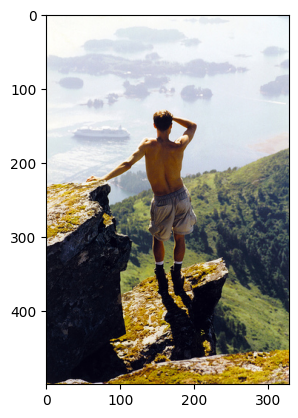

In [111]:
img = cv2.imread(path_test[2])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [112]:
beam_evaluate(path_test[2])

'a man is climbing a rock'

#### 3.3. Evaluation in all dataset and visualization

In [113]:
def plot_attmap(caption, weights, image):

    fig = plt.figure(figsize=(10, 10))
    temp_img = np.array(Image.open(image))
    
    len_cap = len(caption)
    for cap in range(len_cap):
        weights_img = np.reshape(weights[cap], (8,8))
        weights_img = np.array(Image.fromarray(weights_img).resize((224, 224), Image.LANCZOS))
        
        ax = fig.add_subplot(len_cap//2, len_cap//2, cap+1)
        ax.set_title(caption[cap], fontsize=15)
        
        img=ax.imshow(temp_img)
        
        ax.imshow(weights_img, cmap='gist_heat', alpha=0.6,extent=img.get_extent())
        ax.axis('off')
    plt.subplots_adjust(hspace=0.2, wspace=0.2)
    plt.show()

In [114]:
def filt_text(text):
    filt=['<start>','<unk>','<end>'] 
    temp= text.split()
    [temp.remove(j) for k in filt for j in temp if k==j]
    text=' '.join(temp)
    return text

In [124]:
rid = np.random.randint(0, len(path_test))
test_image = path_test[rid]

real_caption = ' '.join([word for word in cap_test[rid].split() if word not in [0]])
real_caption = filt_text(real_caption)

# Evaluate using greedy search
result_greedy, _ = greedy_evaluate(test_image)
pred_caption_greedy = ' '.join(result_greedy).rsplit(' ', 1)[0]

# Evaluate using beam search
pred_caption_beam = beam_evaluate(test_image, beam_index=3)

# Calculate BLEU score for greedy search
reference = real_caption.split()
candidate_greedy = pred_caption_greedy.split()
bleu_greedy = sentence_bleu(reference, candidate_greedy)

# Calculate BLEU score for beam search
candidate_beam = pred_caption_beam.split()
bleu_beam = sentence_bleu(reference, candidate_beam)

print(f"BLEU score for Greedy Search: {bleu_greedy * 100:.2f}")
print(f"BLEU score for Beam Search: {bleu_beam * 100:.2f}")
print(f"Real Caption: {real_caption}")
print(f"Predicted Caption (Greedy): {pred_caption_greedy}")
print(f"Predicted Caption (Beam): {pred_caption_beam}")

BLEU score for Greedy Search: 0.00
BLEU score for Beam Search: 0.00
Real Caption: A bride is throwing her bouquet to several women standing behind her .
Predicted Caption (Greedy): a bride in a bride in a white dress is standing in a
Predicted Caption (Beam): a group of women dressed in fancy dress


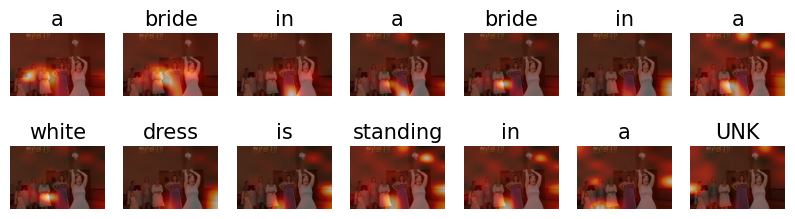

In [125]:
result, attention_plot = greedy_evaluate(test_image)
plot_attmap(result, attention_plot, test_image)

In [126]:
captions=beam_evaluate(test_image)
print(captions)

a group of women dressed in fancy dress


In [121]:
rid = np.random.randint(0, len(path_train))
test_image = path_train[rid]

real_caption = ' '.join([word for word in cap_train[rid].split() if word not in [0]])
real_caption = filt_text(real_caption)

# Evaluate using greedy search
result_greedy, _ = greedy_evaluate(test_image)
pred_caption_greedy = ' '.join(result_greedy).rsplit(' ', 1)[0]

# Evaluate using beam search
pred_caption_beam = beam_evaluate(test_image, beam_index=3)

# Calculate BLEU score for greedy search
reference = real_caption.split()
candidate_greedy = pred_caption_greedy.split()
print(reference, candidate_greedy)
bleu_greedy = sentence_bleu(reference, candidate_greedy)

# Calculate BLEU score for beam search
candidate_beam = pred_caption_beam.split()
bleu_beam = sentence_bleu(reference, candidate_beam)

print(f"BLEU score for Greedy Search: {bleu_greedy * 100:.2f}")
print(f"BLEU score for Beam Search: {bleu_beam * 100:.2f}")
print(f"Real Caption: {real_caption}")
print(f"Predicted Caption (Greedy): {pred_caption_greedy}")
print(f"Predicted Caption (Beam): {pred_caption_beam}")

['Two', 'women', 'in', 'black', 'embrace', 'at', 'crowded', 'outdoor', 'event', '.'] ['a', 'group', 'of', 'people', 'are', 'standing', 'in', 'a']
BLEU score for Greedy Search: 0.00
BLEU score for Beam Search: 0.00
Real Caption: Two women in black embrace at crowded outdoor event .
Predicted Caption (Greedy): a group of people are standing in a
Predicted Caption (Beam): a group of people are watching


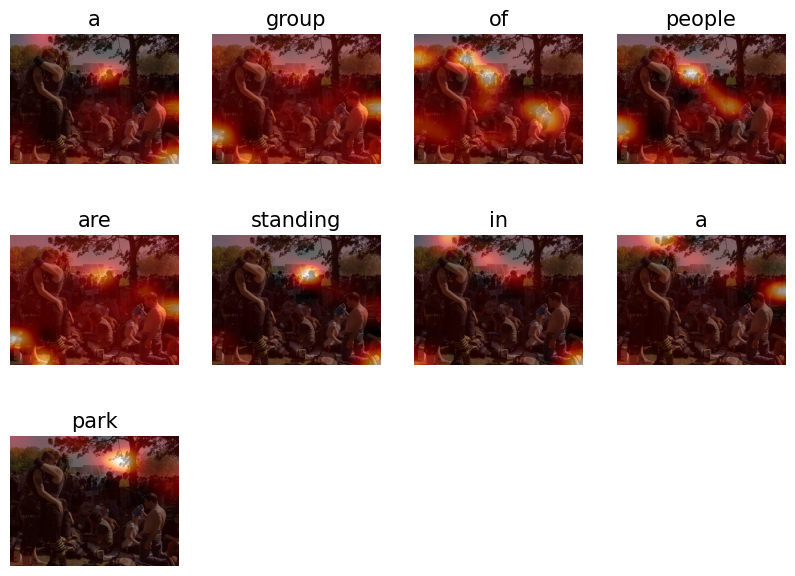

In [122]:
result, attention_plot = greedy_evaluate(test_image)
plot_attmap(result, attention_plot, test_image)

In [123]:
captions=beam_evaluate(test_image)
print(captions)

a group of people are watching
